# 02 â€” Model Training & Evaluation

Trains Random Forest (baseline), XGBoost, and LightGBM. Saves the best model.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed - skipping. pip install xgboost')

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM not installed - skipping. pip install lightgbm')

PROCESSED_PATH = Path('../data/processed.csv')
FEAT_PATH      = Path('../data/feature_list.json')
# Model saved directly into immo_api/models so the API picks it up immediately
MODEL_DIR      = Path('../immo_api/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_PATH)
with open(FEAT_PATH) as f:
    feature_cols = json.load(f)

print(f'Dataset: {df.shape}, Features: {len(feature_cols)}')

Dataset: (92544, 26), Features: 25


## 1. Train / test split

In [2]:
X = df[feature_cols]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (74035, 25), Test: (18509, 25)


## 2. Evaluation helper

In [3]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2   = r2_score(y_te, pred)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    print(f'{name:20s}  RÂ²={r2:.4f}  MAE=â‚¬{mae:,.0f}  RMSE=â‚¬{rmse:,.0f}')
    return {'name': name, 'r2': r2, 'mae': mae, 'rmse': rmse, 'model': model}

results = []

## 3. Baseline â€” Random Forest

In [4]:
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
results.append(evaluate('RandomForest', rf, X_train, y_train, X_test, y_test))

RandomForest          RÂ²=0.8150  MAE=â‚¬68,196  RMSE=â‚¬140,141


## 4. XGBoost

In [5]:
if HAS_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=0
    )
    results.append(evaluate('XGBoost', xgb_model, X_train, y_train, X_test, y_test))

XGBoost               RÂ²=0.8058  MAE=â‚¬75,965  RMSE=â‚¬143,575


## 5. LightGBM

In [6]:
if HAS_LGB:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05,
        num_leaves=63, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbose=-1
    )
    results.append(evaluate('LightGBM', lgb_model, X_train, y_train, X_test, y_test))

LightGBM              RÂ²=0.8097  MAE=â‚¬73,950  RMSE=â‚¬142,140


## 6. Pick best model & tune it

In [7]:
best = max(results, key=lambda r: r['r2'])
print(f"\nBest model: {best['name']}  RÂ²={best['r2']:.4f}")
best_model = best['model']


Best model: RandomForest  RÂ²=0.8150


In [8]:
# Optional: RandomizedSearchCV for the best model
# (comment out if you want to skip tuning to save time)

if best['name'] == 'RandomForest':
    param_dist = {
        'n_estimators': [200, 300, 500],
        'max_depth': [None, 20, 30],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 0.5],
    }
    search = RandomizedSearchCV(
        RandomForestRegressor(n_jobs=-1, random_state=42),
        param_dist, n_iter=20, cv=3, scoring='r2',
        n_jobs=-1, random_state=42, verbose=1
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print('Best params:', search.best_params_)

elif best['name'] == 'XGBoost' and HAS_XGB:
    param_dist = {
        'n_estimators': [300, 500, 800],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
    }
    search = RandomizedSearchCV(
        xgb.XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
        param_dist, n_iter=20, cv=3, scoring='r2',
        n_jobs=-1, random_state=42, verbose=1
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print('Best params:', search.best_params_)

# Re-evaluate after tuning
pred = best_model.predict(X_test)
final_r2  = r2_score(y_test, pred)
final_mae = mean_absolute_error(y_test, pred)
final_rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f'\nTuned {best["name"]}:  RÂ²={final_r2:.4f}  MAE=â‚¬{final_mae:,.0f}  RMSE=â‚¬{final_rmse:,.0f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}



Tuned RandomForest:  RÂ²=0.8203  MAE=â‚¬66,892  RMSE=â‚¬138,106


## 7. Feature importance

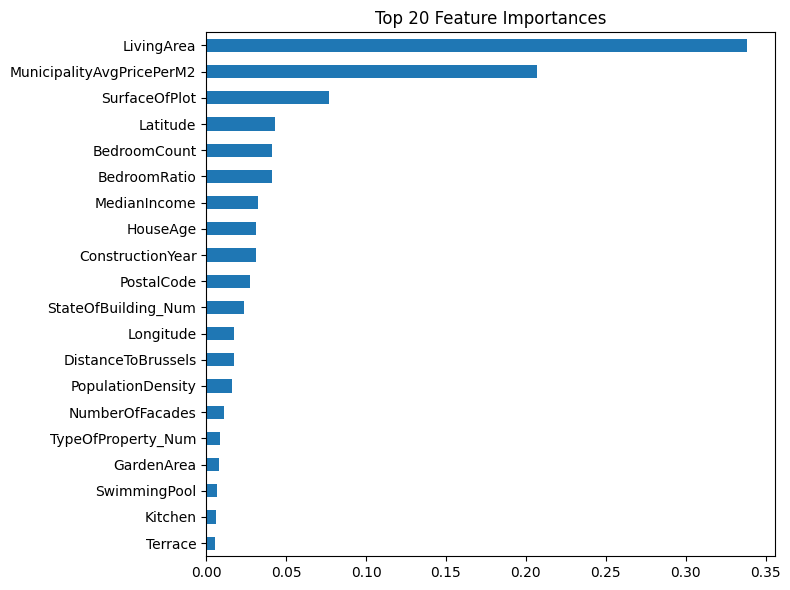

In [9]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=False).head(20)
    imp.plot(kind='barh', figsize=(8, 6), title='Top 20 Feature Importances')
    plt.tight_layout()
    plt.gca().invert_yaxis()
    plt.show()

## 8. Cross-validation (5-fold)

In [10]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'CV RÂ²: {cv_scores.round(4)}  mean={cv_scores.mean():.4f} Â± {cv_scores.std():.4f}')

CV RÂ²: [0.8032 0.8104 0.7869 0.8108 0.7782]  mean=0.7979 Â± 0.0131


## 9. Save model & metadata

In [11]:
model_path = MODEL_DIR / 'model.pkl'
joblib.dump(best_model, model_path)
print(f'Model saved to {model_path}')

metadata = {
    'model_name': best['name'],
    'version': '2.0',
    'trained_at': datetime.now().isoformat(),
    'dataset_size': len(df),
    'r2': round(final_r2, 4),
    'mae': round(final_mae, 2),
    'rmse': round(final_rmse, 2),
    'cv_r2_mean': round(float(cv_scores.mean()), 4),
    'cv_r2_std':  round(float(cv_scores.std()), 4),
    'features': feature_cols,
    'feature_count': len(feature_cols),
}

meta_path = MODEL_DIR / 'model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved to {meta_path}')
print(json.dumps({k: v for k, v in metadata.items() if k != 'features'}, indent=2))

Model saved to ..\immo_api\models\model.pkl
Metadata saved to ..\immo_api\models\model_metadata.json
{
  "model_name": "RandomForest",
  "version": "2.0",
  "trained_at": "2026-03-17T15:41:10.313199",
  "dataset_size": 92544,
  "r2": 0.8203,
  "mae": 66891.73,
  "rmse": 138106.13,
  "cv_r2_mean": 0.7979,
  "cv_r2_std": 0.0131,
  "feature_count": 25
}


## 10. Old vs New model comparison (baseline)

In [12]:
OLD_MODEL = Path('../model.pkl')  # original model.pkl in repo root

if OLD_MODEL.exists():
    old = joblib.load(OLD_MODEL)
    # Old model expected different feature set â€” test on shared features only
    old_features = getattr(old, 'feature_names_in_', None)
    if old_features is not None:
        shared = [f for f in old_features if f in df.columns]
        X_old = df[shared]
        try:
            old_pred = old.predict(X_old)
            old_r2   = r2_score(df['Price'], old_pred)
            old_mae  = mean_absolute_error(df['Price'], old_pred)
            print(f'Old model  RÂ²={old_r2:.4f}  MAE=â‚¬{old_mae:,.0f}')
            print(f'New model  RÂ²={final_r2:.4f}  MAE=â‚¬{final_mae:,.0f}')
            improvement = (final_r2 - old_r2) / abs(old_r2) * 100
            print(f'RÂ² improvement: {improvement:+.1f}%')
        except Exception as e:
            print(f'Could not evaluate old model: {e}')
    else:
        print('Old model has no feature_names_in_ â€” skipping comparison')
else:
    print('Old model.pkl not found â€” skipping comparison')

Old model.pkl not found â€” skipping comparison
